# **Manejo de datos faltantes**


### Índice de temas
1. [Datos ruidosos](#1.-Datos-ruidosos)
    * 1.1 [Tipos de datos ruidosos](#1.1-Tipos-de-datos-ruidosos)
    * 1.2 [Datos Erróneos](#1.2-Datos-Erróneos)
    * 1.3 [Datos Faltantes](#1.3-Datos-Faltantes)
    * 1.4 [Dataset: Primer mirada a los datos](#1.4-Dataset:-Primer-mirada-a-los-datos)
        * 1.4.1 [Exploración](#1.4.1-Exploración)
    * 1.5 [Reconocimiento de datos ruidosos](#1.5-Reconocimiento-de-datos-ruidosos)
        * 1.5.1 [Detección de variables con valor cero](#1.5.1-Detección-de-variables-con-valor-cero)
        * 1.5.2 [Exploración de Bedroom2, Bathroom y Distance](#1.5.2-Exploración-de-Bedroom2,-Bathroom-y-Distance)
        * 1.5.3 [Ejercicio](#1.5.3-Ejercicio)
    * 1.6 [Reconocimiento de datos faltantes](#1.6-Reconocimiento-de-datos-faltantes)
    * 1.7 [Librería Missingno](#1.7-Librería-Missingno)
    * 1.8 [Mecanismos de pérdida de datos (MCAR, MAR, MNAR)](#1.8-Mecanismos-de-pérdida-de-datos)
    * 1.9 [Detección de correlaciones](#1.9-Detección-de-correlaciones)
        * 1.9.1 [Matrix plot](#1.9.1-Detección-de-correlaciones-usando-matrix-plot)
        * 1.9.2 [Heatmap](#1.9.2-Detección-de-correlaciones-usando-Heatmap)
2. [Tratamiento del valor faltante](#2.-Tratamiento-del-valor-faltante)
    * 2.1 [Eliminación de datos faltantes](#2.1-Eliminación-de-datos-faltantes)
        * 2.1.1 [Eliminación de casos completos](#2.1.1-Eliminación-de-casos-completos)
        * 2.1.2 [Eliminación de variables](#2.1.2-Eliminación-de-variables)
    * 2.2 [Técnicas de imputación básicas](#2.2-Técnicas-de-imputación)
        * 2.2.1 [Imputar con constante](#2.2.1-Técnicas-Básicas)
        * 2.2.2 [Imputar con valor más frecuente](#2.2.2-Imputar-con-el-valor-más-frecuente)
        * 2.2.3 [Imputar con la media](#2.2.3-Ejercicio:-Imputar-con-la-media)
        * 2.2.4 [Hot Deck](#2.2.4-Hot-Deck)
    * 2.3 [Técnicas de imputación avanzadas](#2.3-Técnicas-de-imputación-avanzadas)
        * 2.3.1 [K-Nearest Neighbor](#2.3.1-K-Nearest-Neighbor-Imputation)
        * 2.3.2 [MICE - Multivariate feature imputation](#2.3.2-Multivariate-feature-imputation)
        * 2.3.3 [Ejercicio](#2.3.3-Ejercicio)
        * 2.3.4 [Otros métodos](#2.3.4-Otros-métodos-de-imputación)


## ⚙️ Configuración inicial

Ejecutar esta celda **antes de cualquier otra**. Instala las librerías necesarias e importa todo lo requerido para el notebook.

In [1]:
# Instalación de dependencias (ejecutar una sola vez)
# !pip install missingno fancyimpute

# Librerías estándar
import numpy as np
import pandas as pd

# Configuración de pandas para cambiar el formatod de como salen los floats
#pd.set_option para configuraciones internas.
#display.float_format es el tipo de cambio que se hará
#Luego esta una función anonima para poner cada número
#con solo 2 decimales. (Solo para alteraciones en salidas)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#ajustar el tamaño de las fuentes, líneas y marcadores de los gráficos para
#que se adapaten al medio donde se van a exponer. 
#.set_context ajusta el tamaño de las fuentes
#"talk" es un preajuste disponible, incrementando el tamaño de todos los elementos.
#hay distintas opciones como "paper" para artículos científicos, 'notebook' para dejarlo
#por defecto y 'poster' para que sea grande para posteres de conferencias. 
sns.set_context('paper')
import plotly.express as px

# Para la visualización de datos faltantes
import missingno as msno

# Imputación avanzada - sklearn
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 1. Datos ruidosos

Una de las conclusiones más importantes de trabajar con información es que los datos nunca se organizan ni se recolectan de forma simple. Los datos del mundo real, al combinar diferentes características y calificaciones de objetos y sujetos, muchas veces contienen errores, lo que requiere una limpieza significativa para ser utilizables. Esto es lo que se conoce como **ruido** en los datos.

Casi todos los conjuntos de datos contienen algo de ruido. Algunos tipos de ruido son más fáciles de corregir que otros. A veces, eliminar el ruido por completo es simplemente imposible. Como se dice en procesamiento de datos: <span style="color:FireBrick">**cuando entra basura, sale basura.**</span>

### 1.1 Tipos de datos ruidosos

* El <span style="color:FireBrick">**dato erróneo**</span> es un dato recolectado con algún error, que lo separa de la generalidad. Debe ser inspeccionado y tratado especialmente para determinar si es un <span style="color:FireBrick">**ruido**</span> o un dato importante con baja probabilidad de ocurrir, es decir un <span style="color:FireBrick">**dato atípico**</span> u <span style="color:FireBrick">**outlier**</span>.

* El <span style="color:FireBrick">**dato faltante**</span> es un dato que no está registrado en la base de datos. Dependiendo de cómo se hayan recolectado los datos, pueden estar marcados con un <span style="color:FireBrick">**NaN**</span>, o con un número fuera de rango como <span style="color:FireBrick">**0**</span> o <span style="color:FireBrick">**-1**</span>. Es muy importante reconocer la codificación de datos faltantes para no confundirlos con un dato válido.

Por ejemplo también un dato faltante puede ser 999 o -999 pues es un dato faltante codificado de otra forma. Y esto puede identificarse con análisis descriptivo. 

### 1.2 Datos Erróneos

Los datos erróneos se dividen en <span style="color:FireBrick">**datos atípicos**</span> y <span style="color:FireBrick">**datos mal codificados**</span>.

Los <span style="color:FireBrick">**datos atípicos**</span> son datos reales que pueden producir demasiada palanca sobre los estadísticos de tendencia central, lo cual los hace candidatos a ser retirados del dataset.

Los <span style="color:FireBrick">**datos mal codificados**</span> son la fuente de error más común. Es importante detectar cuando los datos faltantes fueron codificados como valores fuera de rango, por ejemplo el valor <span style="color:FireBrick">**cero**</span>. Este error suele aparecer cuando se mezclan bases de datos con distinta codificación de datos faltantes.

Acá es donde la importancia de un análisis descriptivo y exploratorio sale a la luz, pues directamente con esto es que puede identificarse. 

Además, por eso mismo es que es necesario leer el diccionario de las bases de datos o variables que se tengan, pues, directamente en estos documentos se puede tener este tipo de información para luego, no cometer ningún error. 

### 1.3 Datos Faltantes

Los datos faltantes se dividen en <span style="color:FireBrick">**datos perdidos**</span> y <span style="color:FireBrick">**datos inexistentes**</span>.

* Un <span style="color:FireBrick">**dato perdido**</span> es un dato que existe pero, dada una recolección fallida o incompleta, no se conoce su valor.

* Un <span style="color:FireBrick">**dato inexistente**</span> es un dato que no puede ser recolectado porque sencillamente no existe.

Python no reconoce la diferencia, por lo cual hay que ser cauteloso. Al leer un archivo con espacios en blanco, automáticamente asigna a ese dato un <span style="color:FireBrick">**NaN**</span>.


### 1.4 Dataset: Primer mirada a los datos

Este es el punto en el que entramos en la parte de la ciencia de datos que necesita mucho de la "intuición de datos": mirar realmente los datos y tratar de averiguar por qué son así y cómo esto afecta el análisis.

<span style="color:FireBrick">**Para lidiar con los valores perdidos**</span>, la pregunta más importante es:

> ❓ **¿Falta este valor porque no se registró o porque no existe?**

Por ejemplo:
- Una casa de 2 dormitorios no incluiría respuesta para el tamaño del tercer dormitorio → **no existe** → mantener como `NaN`.
- Alguien que no quiso reportar sus ingresos → **no se registró** → puede intentarse imputar.

Por ello, es importante diferenciar cuando un dato no existe y cuando es porque no hay registro y entonces allí es que puede imputarse. 

Vamos a trabajar con el dataset <span style="color:FireBrick">**Melbourne Housing Snapshot**</span>, un conjunto reducido de información sobre ventas de propiedades.

#### 1.4.1 Exploración

In [2]:
melb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')

print(f"Dimensiones: {melb_data.shape[0]} filas × {melb_data.shape[1]} columnas")
melb_data.shape

Dimensiones: 13580 filas × 21 columnas


(13580, 21)

In [3]:
melb_data.describe() #estadísticos de variables cuantitativas

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


**Definición de variables** (las filas son *casos*, las columnas son *variables*):

| Variable | Descripción |
|---|---|
| `Suburb` | Barrio / región |
| `Rooms` | Número de habitaciones |
| `Price` | Precio en dólares |
| `Type` | `h`=casa, `u`=unidad/duplex, `t`=townhouse |
| `Distance` | Distancia al CBD |
| `Bedroom2` | N° de dormitorios (fuente alternativa) |
| `Bathroom` | Número de baños |
| `Car` | Espacios de estacionamiento |
| `Landsize` | Tamaño del terreno |
| `BuildingArea` | Tamaño de la construcción |
| `YearBuilt` | Año de construcción |
| `CouncilArea` | Consejo municipal de la zona |

In [4]:
y = melb_data.sample(10, random_state=123)
print(y)
#muestra aleatoria de 10 registros, con semilla 123

              Suburb              Address  Rooms Type      Price Method  \
5799        St Kilda  25/69 Wellington St      2    u  542500.00     PI   
10596   Broadmeadows          48 Walsh St      3    h  386000.00      S   
7471      Ascot Vale         17 Monash St      3    h 1230000.00     PI   
2308          Elwood    2/129 Brighton Rd      2    u  684000.00     SP   
2602   Fitzroy North        264 Barkly St      3    h 1600000.00      S   
3159        Hawthorn           16 Pine St      3    h 1712000.00      S   
5781        St Kilda   1/62 Wellington St      1    u  500000.00     SP   
2443        Essendon      1/19 Cameron Rd      2    u  691000.00     SP   
6005        Sunshine        165 Morris St      3    h  591500.00      S   
6365          Toorak    4/264 Williams Rd      2    u  810000.00     SP   

             SellerG        Date  Distance  Postcode  ...  Bathroom  Car  \
5799         McGrath  10/09/2016      6.10   3182.00  ...      1.00 1.00   
10596  hockingstuart  

### 1.5 Reconocimiento de datos ruidosos

En la muestra vemos variables con valores faltantes reconocidos por pandas como <span style="color:FireBrick">**NaN**</span>, y valores <span style="color:FireBrick">**0**</span> que podrían ser también datos faltantes. (Por eso es que un análisis de variable por variable puede ser determinante pues revisar el contexto de cada variable me puede llevar a descubrir cosas más a fondo)

¿Son estos ceros valores posibles o datos faltantes codificados así?

#### 1.5.1 Detección de variables con valor cero

In [5]:
# Conteo de ceros por columna
#axis=0 cuenta por columna. (eje vertical)
cols = melb_data[melb_data == 0].count(axis=0)
cols[cols > 0]
#type(cols)

Distance           6
Bedroom2          16
Bathroom          34
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64

Recordemos que tenemos 13 580 casos. La pregunta a responder es: ¿son estos ceros valores posibles de la variable o datos faltantes codificados como 0?

Vamos a trabajar las variables `Bedroom2`, `Bathroom` y `Distance`.

notese que se tiene muy pocos valores para estas variables por lo que puede consedirarse algo raro que sus valores sean cero. 

#### 1.5.2 Exploración de Bedroom2, Bathroom y Distance

##### Tipos de propiedades SIN DORMITORIOS

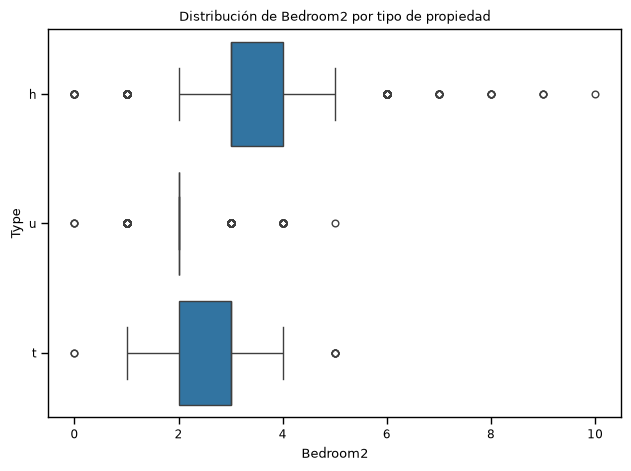

In [6]:
sns.boxplot(data=melb_data[melb_data.Bedroom2 < 20], x='Bedroom2', y='Type')
plt.title('Distribución de Bedroom2 por tipo de propiedad')
plt.tight_layout()

Solo había 16 casos con valores cero. Hay unidades, casas y townhouses sin dormitorios. Podría pensarse en unidades tipo monoambiente, pero es difícil imaginar casas sin dormitorios — ese parece ser un dato faltante, ya que `Bedroom2` proviene de la unión con otra base de datos.

Miremos conjuntamente la variable `Rooms` y la variable `Bedroom2`:

In [7]:
Bedroom2 = melb_data.Bedroom2
Rooms = melb_data.Rooms
#crosstab es como hacer un cont(bedroom2,rooms) en R
pd.crosstab(Bedroom2, Rooms)

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.00,0,5,8,3,0,0,0,0,0
1.00,663,21,5,2,0,0,0,0,0
2.00,16,3539,162,19,1,0,0,0,0
3.00,2,74,5626,175,18,1,0,0,0
4.00,0,8,73,2473,42,4,0,1,0
5.00,0,1,5,15,531,2,2,0,0
6.00,0,0,0,0,2,59,0,2,0
7.00,0,0,0,0,1,1,8,0,0
8.00,0,0,0,0,1,0,0,4,0


La variable `Rooms` es mucho más informativa que `Bedroom2`. Lo que passa es que bedroom2 es un variable que uso al juntar dos data frames. Además, sabemos que 'Rooms' tiene la misma información, por tanto, simplemente podemos eliminar Bedroom2 y ya podría ser un solución simple para ese caso específico. 

##### Acción: eliminar la variable `Bedroom2`

> ⚠️ **NUNCA ACCIONAR SOBRE EL DATASET ORIGINAL** — siempre trabajar sobre una copia.

In [8]:
melb_df = melb_data.copy()
melb_df = melb_df.drop(['Bedroom2'], axis=1) #axis=1 busca en el eje horizontal. 
melb_df.sample(5, random_state=123)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
5799,St Kilda,25/69 Wellington St,2,u,542500.00,PI,McGrath,10/09/2016,6.10,3182.00,1.00,1.00,0.00,NaN,NaN,Port Phillip,-37.86,144.99,Southern Metropolitan,13240.00
10596,Broadmeadows,48 Walsh St,3,h,386000.00,S,hockingstuart,8/07/2017,14.00,3047.00,1.00,1.00,341.00,71.00,1965.00,Hume,-37.69,144.92,Northern Metropolitan,4294.00
7471,Ascot Vale,17 Monash St,3,h,1230000.00,PI,Nelson,20/05/2017,5.90,3032.00,1.00,2.00,538.00,NaN,NaN,Moonee Valley,-37.78,144.91,Western Metropolitan,6567.00
2308,Elwood,2/129 Brighton Rd,2,u,684000.00,SP,McGrath,19/11/2016,7.70,3184.00,1.00,0.00,0.00,98.00,1930.00,Port Phillip,-37.88,144.99,Southern Metropolitan,8989.00
2602,Fitzroy North,264 Barkly St,3,h,1600000.00,S,Collins,25/02/2017,3.50,3068.00,1.00,0.00,370.00,NaN,NaN,Yarra,-37.78,144.99,Northern Metropolitan,6244.00


##### Tipos de propiedades SIN BAÑOS

Esto nos puede dar indiciós de si los valores son problemáticos o no, pues directamente por ejemplo conecontrar una casa sin baño puede ser un error. 

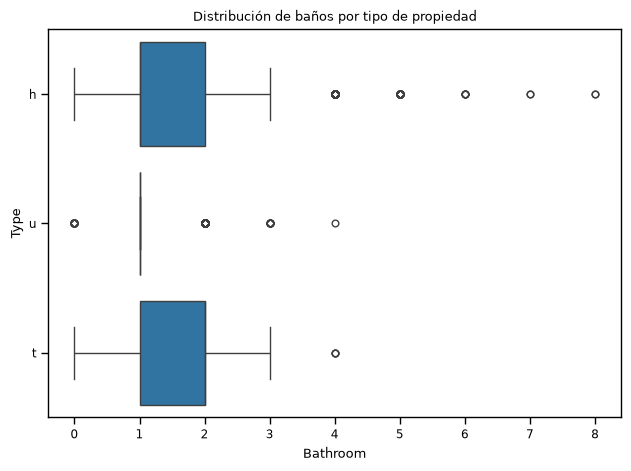

In [9]:
sns.boxplot(data=melb_data, x='Bathroom', y='Type')
plt.title('Distribución de baños por tipo de propiedad')
plt.tight_layout()

In [10]:
Bathroom = melb_data.Bathroom
#Esto es como un count para 2 variables. 
pd.crosstab(Bathroom, Rooms)

#notese que se puede ver los hogares con un número respectivo de baños
#y habitaciones y se a partir de lo anterior es posible usar un filtro para hacer
#estas verificaciones de que tipo de registros estamos hablando. 

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.00,1,19,11,3,0,0,0,0,0
1.00,674,3117,3250,452,17,2,0,0,0
2.00,6,504,2459,1720,260,20,3,2,0
3.00,0,8,153,469,244,35,5,2,1
4.00,0,0,5,41,47,9,2,2,0
5.00,0,0,1,2,25,0,0,0,0
6.00,0,0,2,0,2,1,0,0,0
7.00,0,0,0,0,1,0,0,1,0
8.00,0,0,0,1,0,0,0,1,0


##### Acción: asumir que propiedades sin baños tienen al menos uno

In [11]:
melb_df.loc[melb_df.Bathroom < 1, 'Bathroom'] = 1

# Verificación: ¿quedaron ceros en el dataset editado?

#contar el número de ceros en las filas, para todas las columnas.
# es decir, se toman las columnas verticales como las caterogías.
cols2 = melb_df[melb_df == 0].count(axis=0)
print("Ceros en dataset editado:")
print(cols2[cols2 > 0])
print()
print("Ceros en dataset original:")
print(cols[cols > 0])

Ceros en dataset editado:
Distance           6
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64

Ceros en dataset original:
Distance           6
Bedroom2          16
Bathroom          34
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64


> Como se puede observar: en el dataset editado ya no está `Bedroom2` y la columna `Bathroom` no tiene ceros.

Nota: ES MUY IMPORTANTE QUE TODO TIPO DE EDICIONES Y BÚSQUEDAS SE HAGAN EN UNA COPIA DE LOS DATOS PARA PODER HACER DIFERENTES TIPOS DE BÚSQUEDA SIN AFECTAR NUESTROS DATOS. 

In [12]:
print("Describe original:")
display(melb_data.describe())
print("Describe editado:")
display(melb_df.describe())

Describe original:


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


Describe editado:


,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,1.54,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,1.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


### <span style="color:FireBrick">**1.5.3 Ejercicio**</span>

Dadas las demás columnas del dataset que tienen ceros, decidir para cada una:
1. ¿Es un cero válido o un dato erróneo/faltante enmascarado?
2. ¿Qué acción tomar?

In [13]:
# Revisa las columnas con ceros que aún quedan
cols = melb_data[melb_data == 0].count(axis=0)
cols[cols > 0]
# Tu análisis aquí ↓

Distance           6
Bedroom2          16
Bathroom          34
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64

In [14]:
cols = melb_df[melb_df == 0].count(axis=0)

#forma de obtener los índices del vector(serie)
cols_ceros = cols[cols>0].index # pues acá los índices con los nombres
#de las variables. 

#forma de ver los valores del vector (serie)
cols[cols>0]

Distance           6
Car             1026
Landsize        1939
BuildingArea      17
dtype: int64

In [15]:
cols_ceros

Index(['Distance', 'Car', 'Landsize', 'BuildingArea'], dtype='str')

In [16]:
#A partir de lo anterior las variables que siguen con ceros son: Distance, Car, Landsize y bulding area.

#for i in cols_ceros:
    # Se hace directamente .dtype ya que esto es un ATRIBUTO de al serie de pandas. 
#    print(melb_df[i].dtype)

In [17]:
#Car: Como es simplemente los espacios para parquear autos, no necesriamente
# es un error pues puede ser que sean hogares sin espacio para parquear
melb_df[melb_df['Car'] == 0]
melb_df[melb_df['Car'] == 0].shape # se dejan

(1026, 20)

In [18]:
#Distance al downtown, obligatoriamente debe tener una distancia
#al centro de la ciudad,no? tal vez se pueda corregir imputando
#con los valores de los hogares que tengan las misma dirección
#pero que esta variable no sea cero. 
melb_df[melb_df['Distance'] == 0].shape #son 6
melb_df[melb_df['Distance'] == 0] #son 6

#miremos la dirección y area conuncil de los que son 0
#al seleccionar las variables con [[v1,v2,...]] es como
#un select y hacer [v1] es directamente un pull

melb_df[(melb_df['Distance'] == 0)][['Address','Suburb','CouncilArea']]

#direccion = melb_df[(melb_df['Distance'] == 0)]['Address']
sub = melb_df[(melb_df['Distance'] == 0)]['Suburb']
council = melb_df[(melb_df['Distance'] == 0)]['CouncilArea']

#Ahora de los que son diferente de cero, pero que sean
# del suburbio o council area de los que si 
melb_df[(melb_df['Suburb'].isin(sub))&
        (melb_df['CouncilArea'].isin(council))&
        (melb_df['Distance']!=0)][['Suburb','Distance']]

# es notable que para todos estos casos la distancia es de 2.8
#por tanto, los ceros, pasana ser 2.8

melb_df['Distance'].dtype


#melb_df[melb_df['Distance']==0]['Distance'] = 2.8
#Esta forma anterior crea una copia la cual hace que python no sepa
#si debe guardar la modificació o no, esto solo sirve para
#hacer un filtro rápido, sin embargo, también es más recomendable con 
#.loc


melb_df.loc[melb_df['Distance']==0, 'Distance'] = 2.8 #forma recomendada
#que se hace directamente en el data frame original y no en una copia que pueda
#perderse. Al usar .loc se va directamente al espacio de la memoria de este
#data.frame y por tanto es muchisimo más rápido. 

In [19]:
melb_df.loc[melb_df['Distance']!=0, ['Distance']]

,Distance
0,2.50
1,2.50
2,2.50
3,2.50
4,2.50
...,...
13575,16.70
13576,6.80
13577,6.80
13578,6.80



| `Suburb` | Barrio / región |

| `Rooms` | Número de habitaciones |

| `Price` | Precio en dólares |

| `Type` | `h`=casa, `u`=unidad/duplex, `t`=townhouse |

| `Distance` | Distancia al CBD |

| `Bedroom2` | N° de dormitorios (fuente alternativa) |

| `Bathroom` | Número de baños |

| `Car` | Espacios de estacionamiento |

| `Landsize` | Tamaño del terreno |

| `BuildingArea` | Tamaño de la construcción |

| `YearBuilt` | Año de construcción |

| `CouncilArea` | Consejo municipal de la zona |

<font color="yellow">
Nota:

Pandas.series: Es una estructura UNIDIMENSIONAL indexado capaz de contener cualquier tipo de dato. UNA SOLA DIMENSIÓN. Suelen aparecer como el subproducto de un dataframe aparecen cuando se opera sobre una sola variable, por ejemplo,

* Extraer una variable de un data frame.
    ej: df['variable']
* Realizar operaciones de reducción como .sum(), .count() o .mean(). sobre un data frame.

La serie de panda equivale al vector del R, por ejemplo al hacer un pull para obtener la columna de un data.frame. Pero ojo, acá el vector de numpy es diferente a la serie de pandas. 

¿Diferencia entre una serie de pandas y un vector de numpy?
La serie de pandas es una capa superior estructurada, mientras que el vector de Numpy son los datos puros en memoria. 

La serie de pandas maneja índices explícitos para la identificación de cada fila, cosa que el vector de numpy solo tiene identificación mediante índices numéricos. 

Igualmente es posible pasar de serie a vector de numpy con .to_numpy()

La serie ESTA DISEÑADA PARA ANALÍTICA DE DATOS, por lo que maneja de forma nativa e inteligente los datos faltantes


Pandas.DataFrame: Es un tabla de filas y columnas que es un diccionario de series donde todas las series comparten el mismo índice. VARIAS DIMENSIONES. Es directamente el estandar para la representación y manipúlación de datos tabulares. 

Es como en el select del R, que los datos siguen siendo de tipo de dato data.frame. 
</font>

### 1.6 Reconocimiento de datos faltantes

Las bibliotecas de Python representan los números faltantes como <span style="color:FireBrick">**NaN**</span> (*Not a Number*). Detectar cuántos hay y dónde es el primer paso antes de cualquier tratamiento.

**Consecuencias de los datos faltantes:**
- Limitan la capacidad de convertir tipos de datos o visualizar información.
- Reducen el poder estadístico (aumentan la probabilidad de error Tipo II).
- Reducen la representatividad de las muestras.
- Pueden llevar a **conclusiones inválidas** si no se tratan correctamente.

In [20]:
melb_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [21]:
missing_values_count = melb_data.isna().sum() # sumar el número de registros NA
#por cada una de las columnas. 
missing_values_count

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [22]:
melb_data['CouncilArea']

0        Yarra
1        Yarra
2        Yarra
3        Yarra
4        Yarra
         ...  
13575      NaN
13576      NaN
13577      NaN
13578      NaN
13579      NaN
Name: CouncilArea, Length: 13580, dtype: str

El dataset donde empezamos a corregir:

In [23]:
melb_df.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [24]:
# Porcentaje total de datos faltantes
total_cells = melb_data.shape[0]*melb_data.shape[1]#filas x columnas, total de celdas

total_missing = missing_values_count.sum() #suma de todos los NA

pct = (total_missing / total_cells) * 100 #calcular porcentaje

print(f"Porcentaje de datos faltantes: {pct:.2f}%")

Porcentaje de datos faltantes: 4.65%


Solo hay un **~4% de datos faltantes**, concentrados en cuatro variables:

| Variable | Faltantes | Tipo |
|---|---|---|
| `Car` | 62 | float64 |
| `BuildingArea` | 6 450 | float64 |
| `YearBuilt` | 5 375 | float64 |
| `CouncilArea` | 1 369 | object |

> La imputación es diferente para variables **categóricas** y **numéricas**, por lo cual es importante distinguir los casos.

¿Porcentaje aceptable de datos faltantes? La literatura dice que hasta un 20% se aceptan datos faltantes en una variable. Pero obvio, depende el contexto. 

Si la metodología permite manejar de manera robústa los datos faltantes pues entonces se pueden aceptar mayor porcentaje de datos faltantes. 

Si una variable tiene un 70% de datos faltantes, pero a la hora de entrenar un modelo me da un "information value" muy alto entonces no puedo eliminar esa variable y por tanto es necesario dejarla.



 

### 1.7 Librería Missingno

Text(0.5, 1.0, 'Completitud por variable')

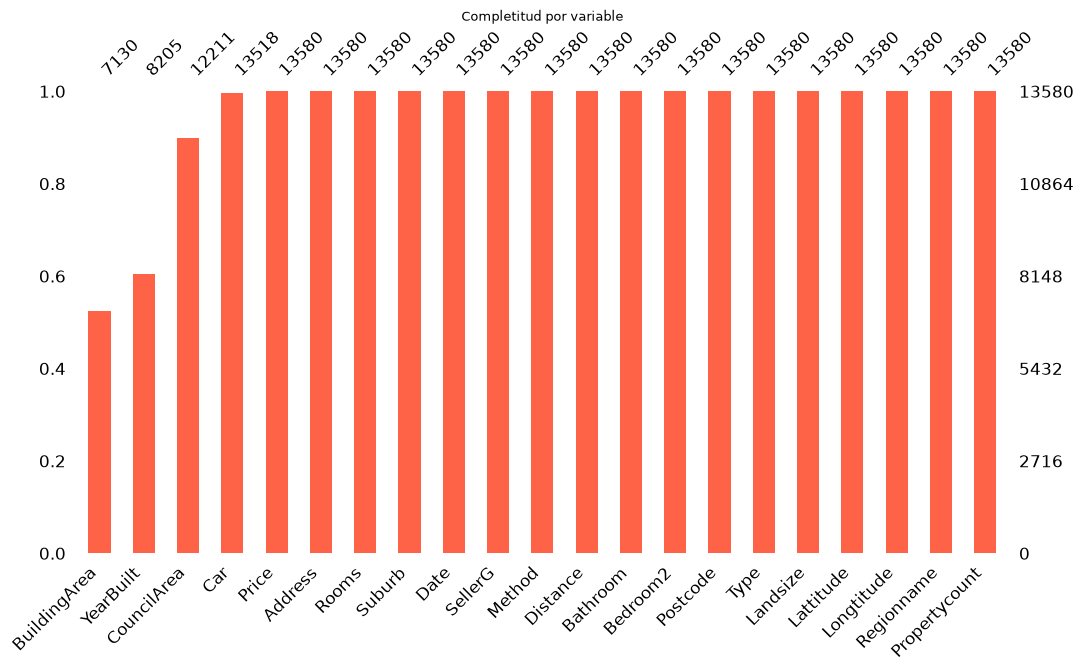

In [25]:
#veamos los valores faltantes por columna con un gráfico
msno.bar(melb_data, figsize=(12, 6), sort="ascending", fontsize=12, color='tomato')

plt.title('Completitud por variable')

Podemos visualizar también las **posiciones** de los datos faltantes en el dataset usando `matrix()`. El gráfico aparece en blanco donde faltan valores.

<Axes: >

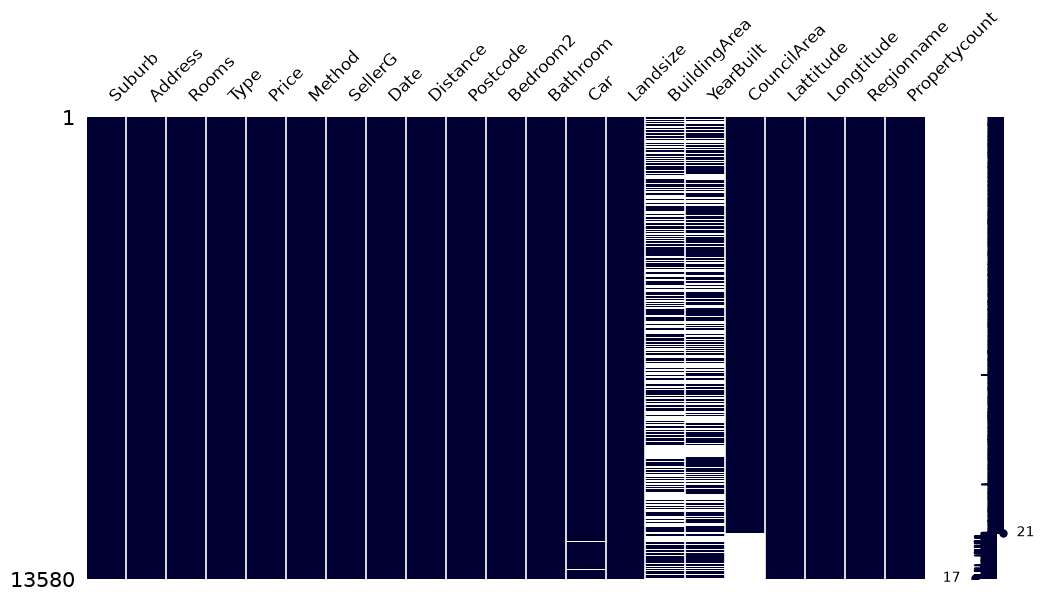

In [26]:
msno.matrix(melb_data, figsize=(12, 6), fontsize=12, color=[0, 0, 0.2])

Con una muestra de 200 datos, podemos observar mejor las correlaciones entre los datos faltantes. Para poder accionar sin incorporar nuevos errores, es necesario corroborar que el mecanismo de pérdida sea aleatorio.

<Axes: >

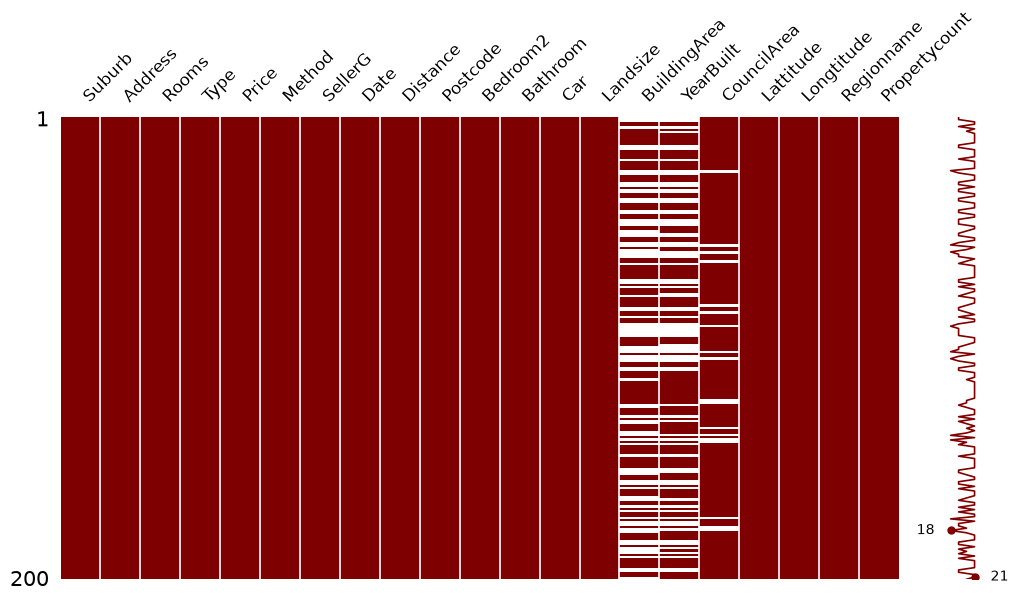

In [27]:
msno.matrix(melb_data.sample(200), figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

### 1.8 Mecanismos de pérdida de datos

> 💡 Este tema fue cubierto en la Semana 5 del curso. Antes de tratar los datos faltantes, es **fundamental** entender por qué faltan.

Se distinguen tres mecanismos estándar:

---

#### <span style="color:Red">1. MCAR — *Missing Completely at Random*</span>

Los valores faltantes de una variable **no están asociados** con otras variables del dataset ni con la misma variable.

**Implicación práctica:** Los datos observados son una muestra aleatoria de todos los datos. Las operaciones simples de Pandas (medias, varianzas) **no se ven afectadas**.

---

#### <span style="color:Red">2. MAR — *Missing at Random*</span>

La pérdida **no es aleatoria**, pero puede ser explicada completamente como función de **otras variables con información completa**.

**Ejemplo en nuestro dataset:** `YearBuilt` podría faltar más frecuentemente en propiedades más antiguas, pero eso está explicado por otras variables disponibles.

**Implicación práctica:** Se puede imputar usando las variables observadas como predictores.

---

#### <span style="color:Red">3. MNAR — *Missing Not at Random*</span>

La pérdida **depende del valor perdido mismo** o de datos no observados.

**Ejemplo:** Los ingresos altos tienden a no ser reportados (el valor faltante está relacionado con ser alto).

**Implicación práctica:** El más difícil de tratar. La imputación estándar puede introducir sesgos importantes.

---

> ⚠️ **¿Por qué importa conocer el mecanismo?**
> Porque la decisión de eliminar casos, eliminar columnas o imputar **depende del tipo de mecanismo**. Eliminar filas en un escenario MNAR introduce sesgos graves.

### 1.9 Detección de correlaciones

La existencia de correlación entre la presencia/ausencia de datos faltantes en determinadas variables es una señal de **falta de aleatoriedad** en el mecanismo de pérdida (descarta MCAR). Aún así, puede existir una relación entre variables que permita imputar el dato perdido.

#### 1.9.1 Detección de correlaciones usando matrix plot

La variable `Car` tiene pocos datos faltantes. Es razonable pensar que es un error de carga, ya que cero en esta variable implicaría que la propiedad no tiene espacio para estacionar.

In [28]:
Car = melb_data.Car

#px usa gráficos interactivos
fig = px.histogram(Car, nbins=100,
                   labels={'value': 'Car', 'count': 'Número de casas'},
                   marginal='violin',
                   title='Distribución de espacios de estacionamiento en Melbourne',
                   color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

Es un poco raro que haya tantas casas sin estacionamiento, y también es inusual que haya casas con 10 espacios.

In [29]:
Car = melb_data.Car
Type = melb_data.Type
pd.crosstab(Type, Car)
#un count entre el tipo de hogares y el número
#de parqueaderos para ver si hay una relación 
#entre los hogares que dicen no tener parqueadero

Car,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00
Type,,,,,,,,,,,
h,846,2681,4524,702,499,63,54,7,9,1,3
t,15,492,584,19,4,0,0,0,0,0,0
u,165,2336,483,27,3,0,0,1,0,0,0


<Axes: >

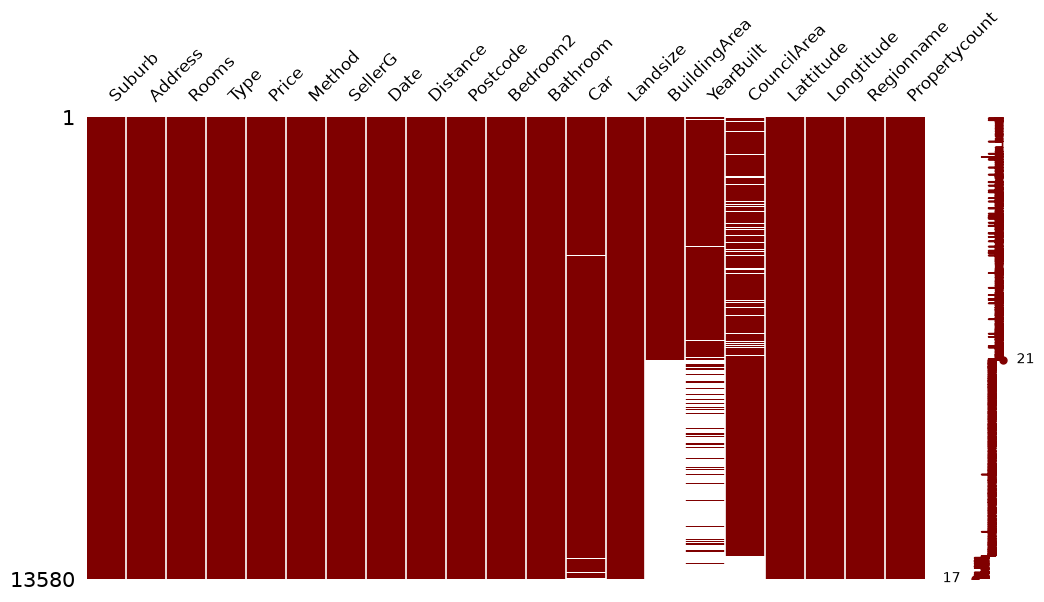

In [30]:
sorted_df = melb_data.sort_values('BuildingArea')
msno.matrix(sorted_df, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

#### 1.9.2 Detección de correlaciones usando Heatmap

El heatmap muestra correlaciones entre columnas que tienen datos faltantes.

| Correlación | Interpretación |
|---|---|
| **-1** | Si el valor de una variable está presente, en la otra está ausente |
| **0** | No se puede ver una relación lineal |
| **+1** | Si una variable tiene valor, la otra definitivamente también |

<Axes: >

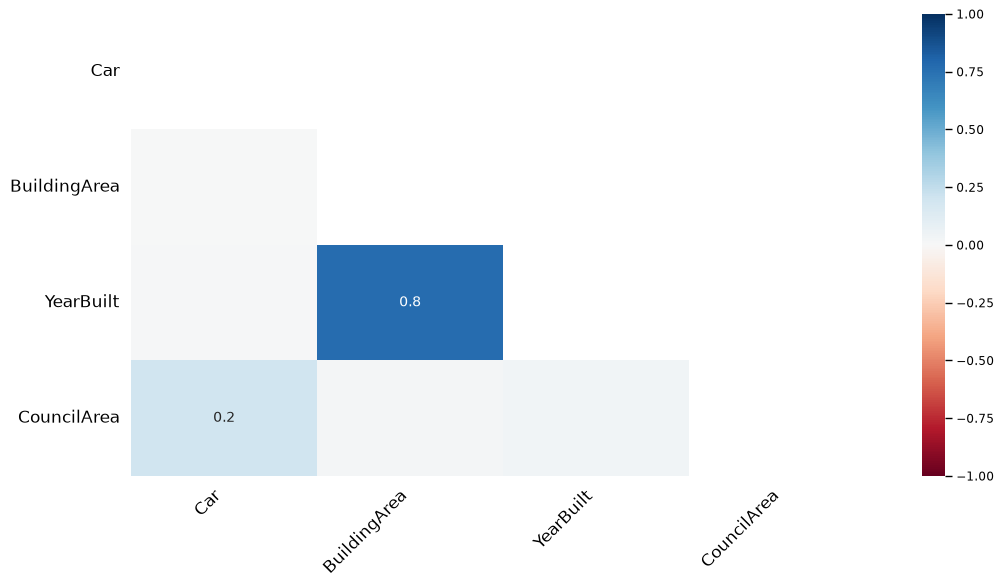

In [31]:
msno.heatmap(melb_data, figsize=(12, 6), fontsize=12)

La aleatoriedad no es completa: hay **alta correlación entre `YearBuilt` y `BuildingArea`**. Esto sugiere un mecanismo **MAR** — ambas tienden a faltar juntas, posiblemente en propiedades más antiguas donde esta información no fue registrada.

Aún así, es posible utilizar imputación estocástica controlando el nivel de error.

## 2. Tratamiento del valor faltante

![diagrama-datos-faltantes.png](https://github.com/DiploDatos/AnalisisYCuracion/blob/master/diagrama-datos-faltantes.png?raw=true)

La decisión de qué hacer con los datos faltantes depende del **mecanismo de pérdida** identificado en la sección anterior:

| Mecanismo | Estrategia recomendada |
|---|---|
| **MCAR** | Eliminación de casos es aceptable si el % es pequeño |
| **MAR** | Imputación (básica o avanzada) usando otras variables |
| **MNAR** | Imputación avanzada; tratar con mucho cuidado los sesgos |

### 2.1 Eliminación de datos faltantes

Si la pérdida es completamente aleatoria (MCAR), las operaciones simples de Pandas que ignoran NaN no se ven afectadas. Sin embargo, operaciones más complejas pueden verse afectadas.

#### 2.1.1 Eliminación de **casos** completos

Si la pérdida es MCAR y el porcentaje de casos con datos faltantes es pequeño, se elimina el caso completo.

In [32]:
# La media de Car (pandas omite NaN automáticamente)
print(f"Media de Car (con NaN): {melb_df['Car'].mean():.2f}")

Media de Car (con NaN): 1.61


In [33]:
melb_df.dropna(subset=['Car'], how='any', inplace=True)
print(f"NaN en Car después de eliminar: {melb_df['Car'].isnull().sum()}")

NaN en Car después de eliminar: 0


Text(0.5, 1.0, 'Completitud después de eliminar casos con Car=NaN')

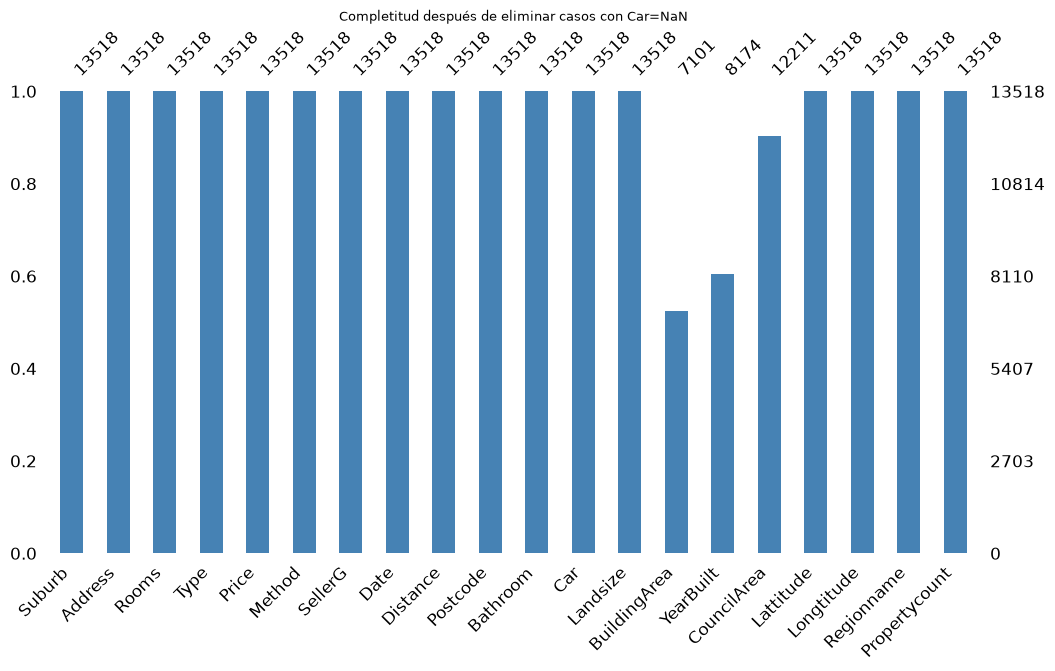

In [34]:
msno.bar(melb_df, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Completitud después de eliminar casos con Car=NaN')

NOTA: ELIMINAR DATOS O VARIABLES NO SIEMPRE ES BUENA IDEA, PUES HAY METOLOGÍAS ROBUSTAS A DATOS FALTANTES Y SI SE ELIMINA INFORMACIÓN QUE PUEDE SER SIGNIFICATIVA A LOS DATAS PUEDE SER UN GRAVE ERROR. 

SI ES UNA BUENA OPCIÓN SI HAY DUPLICIDAD O MULTICOLINEALIDAD ENTRE LAS VARIABLES. ES DECIR, CORRELACIONES BASTANTE ALTAS ENTRE LAS VARIABLES.  

#### 2.1.2 Eliminación de variables

Si una columna contiene **muchos valores faltantes** (>80%) y no es significativa, puede eliminarse. Sin embargo, no es una buena metodología en general ya que se pierde información útil.

> ⚠️ Además, si los datos de prueba tienen faltantes donde los datos de entrenamiento no los tienen, se producirá un error en el modelo.

**Eliminación de todas las columnas con datos faltantes** (solo para ilustrar):

<Axes: >

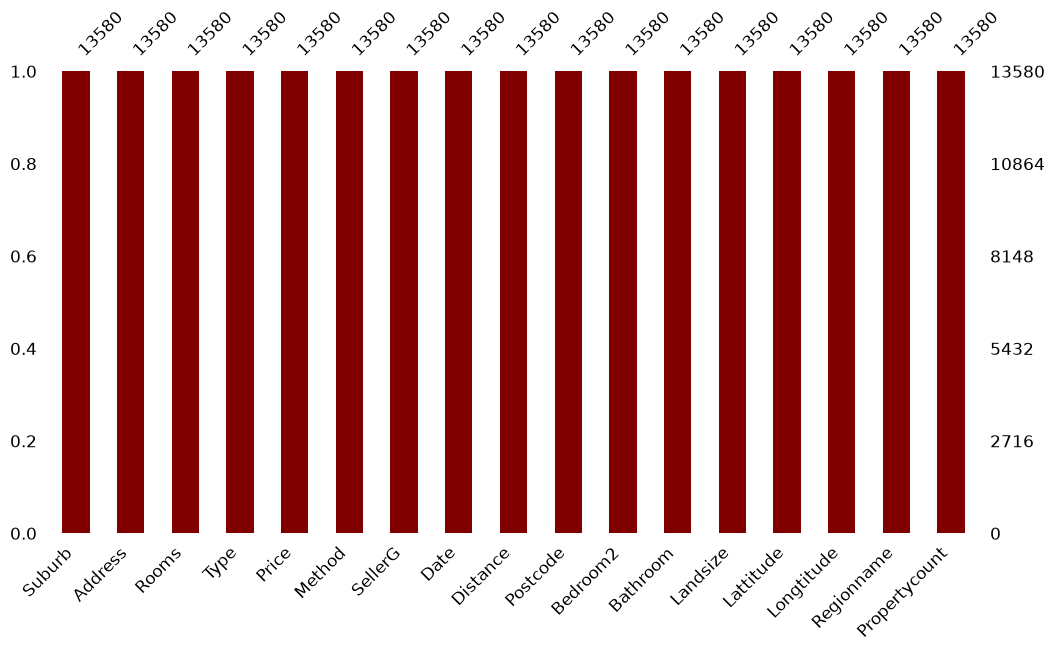

In [35]:
melb_data_without_missing = melb_data.dropna(axis=1)
msno.bar(melb_data_without_missing, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

**Eliminación de `CouncilArea`** — variable categórica con muchos faltantes y baja relevancia predictiva:

Text(0.5, 1.0, 'Completitud después de eliminar CouncilArea')

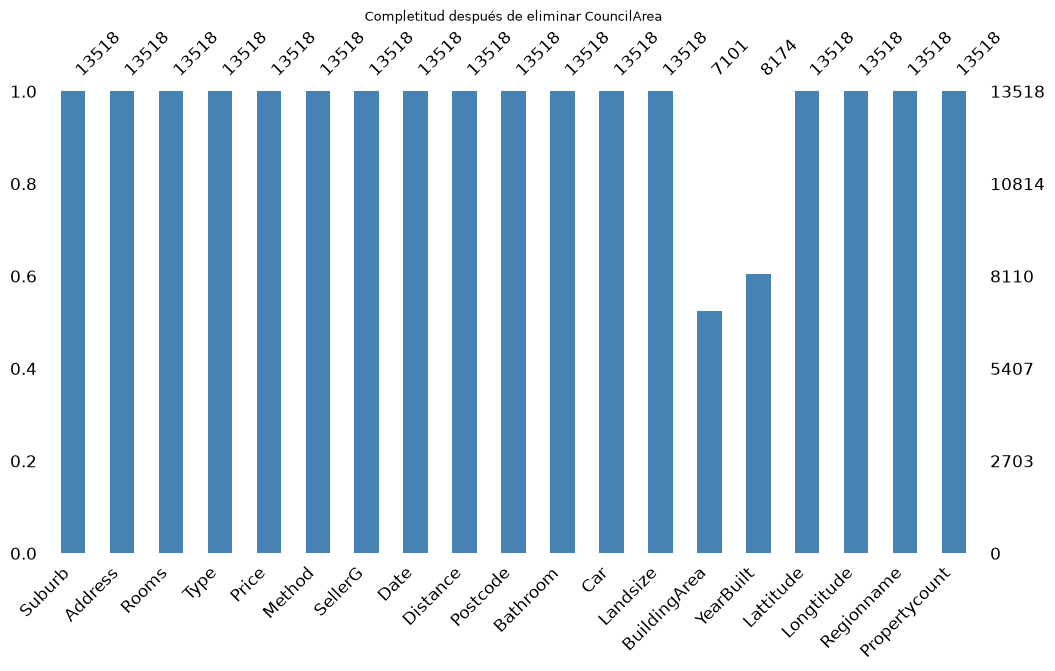

In [36]:
melb_df = melb_df.drop('CouncilArea', axis=1)
msno.bar(melb_df, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Completitud después de eliminar CouncilArea')

### 2.2 Técnicas de imputación

Imputar refiere a reemplazar datos faltantes con valores sustitutos. Según la complejidad, se clasifican en **básicas** y **avanzadas**.

**Técnicas básicas** — reemplazan el dato faltante por:
- Un valor constante con significado en el dominio.
- La media, mediana o moda de la columna.
- Un valor de otro registro seleccionado al azar.

**Técnicas avanzadas** — reemplazan el dato faltante por:
- Un valor estimado por un modelo predictivo.

#### 2.2.1 Técnicas Básicas — Imputar con constante

Text(0.5, 1.0, 'Después de imputar con constante (0)')

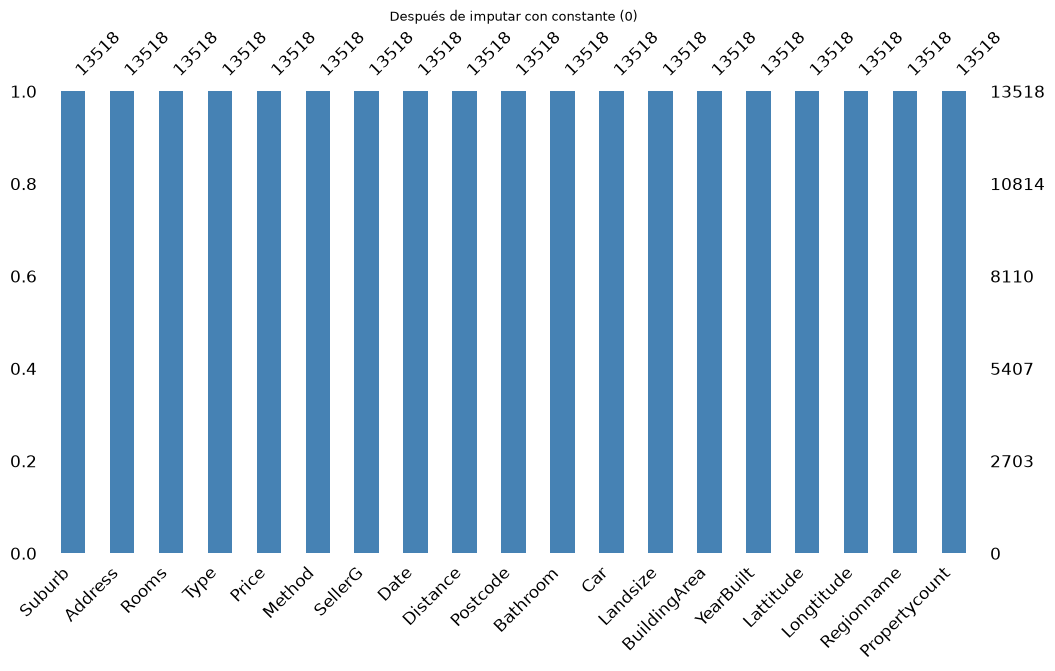

In [37]:
from sklearn.impute import SimpleImputer

melb_data_constant = melb_df.copy()

# Imputar con cero (constante)
#se crea el imputador para que los datos faltantes 
#se llenen con un valor constante y sea cero
mean_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=0)

#aplicar reemplazo.
#en la ram directamente donde está el data frame 
#Primero, fit analiza las columnas para entender
# su estructura, y transform realiza el reemplazo
# físico de todos los NaN por $0$. Esto devuelve
# una matriz de NumPy limpia.
melb_data_constant.iloc[:, :] = mean_imputer.fit_transform(melb_data_constant)

msno.bar(melb_data_constant, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputar con constante (0)')

In [38]:
melb_data_constant.sample(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount
9970,Mount Waverley,3/20 Briggs St,4,t,970000.00,SP,Buxton,24/06/2017,14.20,3149.00,2.00,2.00,196.00,0.00,0.00,-37.89,145.11,Eastern Metropolitan,13366.00
8528,Yarraville,54 Tongue St,4,h,2035000.00,S,Jas,8/04/2017,7.00,3013.00,2.00,0.00,607.00,201.00,1890.00,-37.81,144.89,Western Metropolitan,6543.00
10087,West Footscray,243 Essex St,2,h,749000.00,S,Jas,24/06/2017,6.40,3012.00,1.00,1.00,369.00,0.00,0.00,-37.79,144.86,Western Metropolitan,5058.00
8376,South Yarra,26 Howitt St,2,u,851000.00,S,Biggin,20/05/2017,3.30,3141.00,1.00,1.00,284.00,0.00,0.00,-37.85,145.00,Southern Metropolitan,14887.00
12262,Coburg,87 Phillips St,3,h,1210000.00,S,McDonald,3/09/2017,6.70,3058.00,1.00,4.00,460.00,141.00,1920.00,-37.75,144.95,Northern Metropolitan,11204.00
12663,Brunswick,176 Albert St,2,h,911000.00,SP,Nelson,16/09/2017,5.20,3056.00,1.00,1.00,132.00,77.00,1905.00,-37.77,144.97,Northern Metropolitan,11918.00
3982,Melbourne,805/300 Swanston St,2,u,665000.00,S,Purplebricks,7/11/2016,2.80,3000.00,1.00,1.00,0.00,80.00,2004.00,-37.81,144.96,Northern Metropolitan,17496.00
6551,Williamstown,11 Sandpiper Pl,4,h,2440000.00,S,Sweeney,27/11/2016,8.00,3016.00,3.00,3.00,500.00,278.00,2005.00,-37.86,144.88,Western Metropolitan,6380.00
6850,Carlton,425 Cardigan St,4,h,2345000.00,S,Woodards,28/08/2016,1.80,3053.00,1.00,1.00,284.00,0.00,0.00,-37.80,144.97,Northern Metropolitan,6786.00
10664,Essendon,13 Gordon St,3,h,1398000.00,SP,Barry,8/07/2017,7.50,3040.00,2.00,1.00,445.00,182.00,1960.00,-37.76,144.93,Western Metropolitan,9264.00


**Pros:**
- Trabaja con variables categóricas **sin necesidad de encodings**, agregando una categoría más.

**Cons:**
- No tiene en cuenta las correlaciones entre las variables.
- Puede introducir **sesgos** en los datos.
- Tiene sentido solo cuando la categoría a agregar tiene significado en el dominio.

#### 2.2.2 Imputar con el valor más frecuente

Text(0.5, 1.0, 'Después de imputar con valor más frecuente')

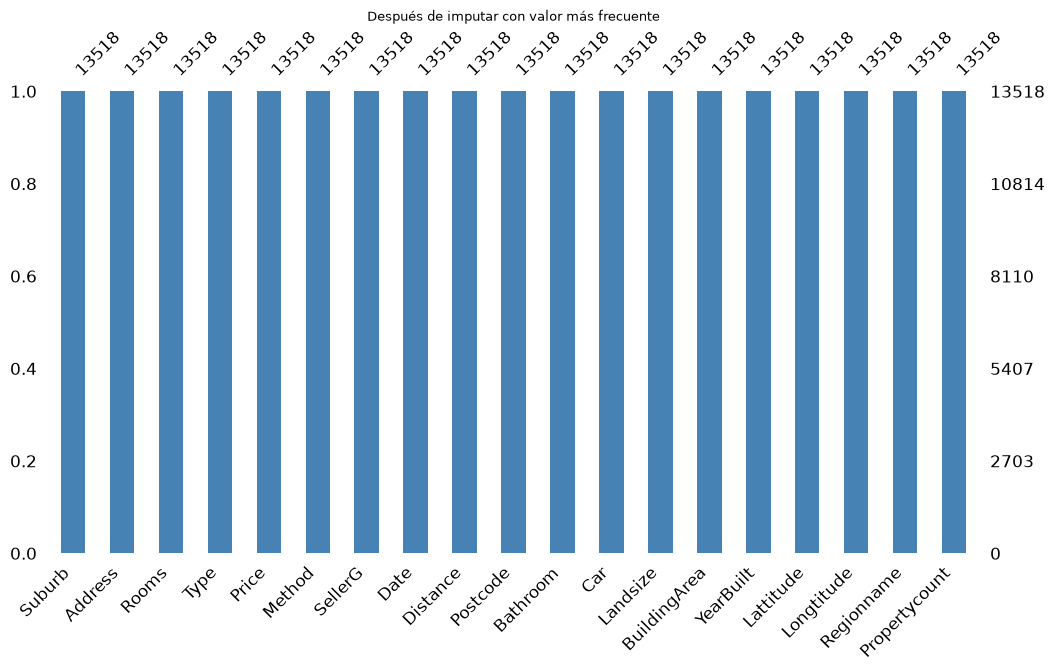

In [39]:
#crear la copia
melb_data_most_frequent = melb_df.copy()

#instancia del imputador con la estrategia del más frecuente
mean_imputer = SimpleImputer(strategy='most_frequent')

#aplicar el reemplazo
melb_data_most_frequent.iloc[:, :] = mean_imputer.fit_transform(melb_data_most_frequent)

msno.bar(melb_data_most_frequent, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputar con valor más frecuente')

In [40]:
melb_data_most_frequent.sample(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount
4453,Northcote,9 Brooke St,2,h,1255000.00,S,Ray,18/03/2017,5.50,3070.00,1.00,2.00,314.00,120.00,1970.00,-37.78,145.00,Northern Metropolitan,11364.00
2159,Doncaster,31 Massey St,3,h,900000.00,PI,Ray,16/07/2016,13.90,3108.00,2.00,2.00,366.00,150.00,2013.00,-37.79,145.11,Eastern Metropolitan,9028.00
13008,Keilor East,41 Patricia St,4,h,1250000.00,S,Nelson,19/08/2017,11.70,3033.00,2.00,2.00,534.00,211.00,1970.00,-37.75,144.87,Western Metropolitan,5629.00
11353,Essendon North,2/9 McCulloch St,2,u,785000.00,S,Nelson,15/07/2017,8.20,3041.00,1.00,2.00,145.00,120.00,1970.00,-37.74,144.90,Western Metropolitan,1308.00
9960,Mitcham,8 Tourello St,3,h,960000.00,VB,Noel,24/06/2017,17.20,3132.00,1.00,0.00,781.00,120.00,1970.00,-37.81,145.20,Eastern Metropolitan,6871.00
230,Armadale,1/77 Wattletree Rd,2,u,660000.00,SP,hockingstuart,4/03/2017,6.30,3143.00,1.00,1.00,0.00,120.00,1970.00,-37.86,145.03,Southern Metropolitan,4836.00
9213,Keysborough,2 Eildon Dr,4,h,745000.00,S,C21,3/06/2017,25.20,3173.00,2.00,1.00,624.00,159.00,1969.00,-37.99,145.16,South-Eastern Metropolitan,8459.00
2310,Elwood,6/26 Ruskin St,2,u,500000.00,VB,Wilson,22/05/2016,7.70,3184.00,1.00,1.00,0.00,63.00,1970.00,-37.88,144.98,Southern Metropolitan,8989.00
6777,Brunswick East,178 Weston St,2,h,1080000.00,S,Greg,10/09/2016,4.50,3057.00,1.00,0.00,193.00,101.00,1890.00,-37.78,144.98,Northern Metropolitan,5533.00
7486,Avondale Heights,30 Lorgrove Ct,4,h,1600000.00,VB,Nelson,29/04/2017,10.50,3034.00,3.00,3.00,857.00,120.00,1970.00,-37.76,144.87,Western Metropolitan,4502.00


**Pros:**
- Anda bien con variables categóricas **sin necesidad de encodings**.

**Cons:**
- No tiene en cuenta las correlaciones entre las variables.
- Puede introducir **sesgos** en los datos.

#### 2.2.3 Ejercicio: Imputar con la media

Imputar las columnas con datos faltantes utilizando la **media**. Recuerda que este método:

**Pros:**
- Rápido y fácil.
- Anda bien con datasets numéricos bien balanceados.

**Cons:**
- No tiene en cuenta las correlaciones entre las variables.
- Solo trabaja a nivel de columna.
- **No debe usarse con variables categóricas**.
- No es muy preciso y no hay cómputo para el error.

In [49]:
# Para poder imputar con la media esto solo puede hacerse
#con variables numércias, por tanto, a las variables categóricas 
#hay que llevarlas a numércias con encoding. 

#recordemos que la imputación en este caso es solo
#para las variables BuildingArea y YearBuilt
melb_data_mean = melb_df.copy()
melb_data_mean[['BuildingArea','YearBuilt']].info() # ambos son de tipo numérico

melb_data_mean['BuildingArea'].mean() # ambos son de tipo numérico
melb_data_mean['YearBuilt'].mean() # ambos son de tipo numérico


#type(melb_data_mean[['BuildingArea']]) 

<class 'pandas.DataFrame'>
Index: 13518 entries, 0 to 13579
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BuildingArea  7101 non-null   float64
 1   YearBuilt     8174 non-null   float64
dtypes: float64(2)
memory usage: 316.8 KB


np.float64(1964.896501101052)

In [51]:
melb_data_mean.info()

<class 'pandas.DataFrame'>
Index: 13518 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13518 non-null  str    
 1   Address        13518 non-null  str    
 2   Rooms          13518 non-null  int64  
 3   Type           13518 non-null  str    
 4   Price          13518 non-null  float64
 5   Method         13518 non-null  str    
 6   SellerG        13518 non-null  str    
 7   Date           13518 non-null  str    
 8   Distance       13518 non-null  float64
 9   Postcode       13518 non-null  float64
 10  Bathroom       13518 non-null  float64
 11  Car            13518 non-null  float64
 12  Landsize       13518 non-null  float64
 13  BuildingArea   7101 non-null   float64
 14  YearBuilt      8174 non-null   float64
 15  Lattitude      13518 non-null  float64
 16  Longtitude     13518 non-null  float64
 17  Regionname     13518 non-null  str    
 18  Propertycount  13518 n

Text(0.5, 1.0, 'Después de imputar con Media')

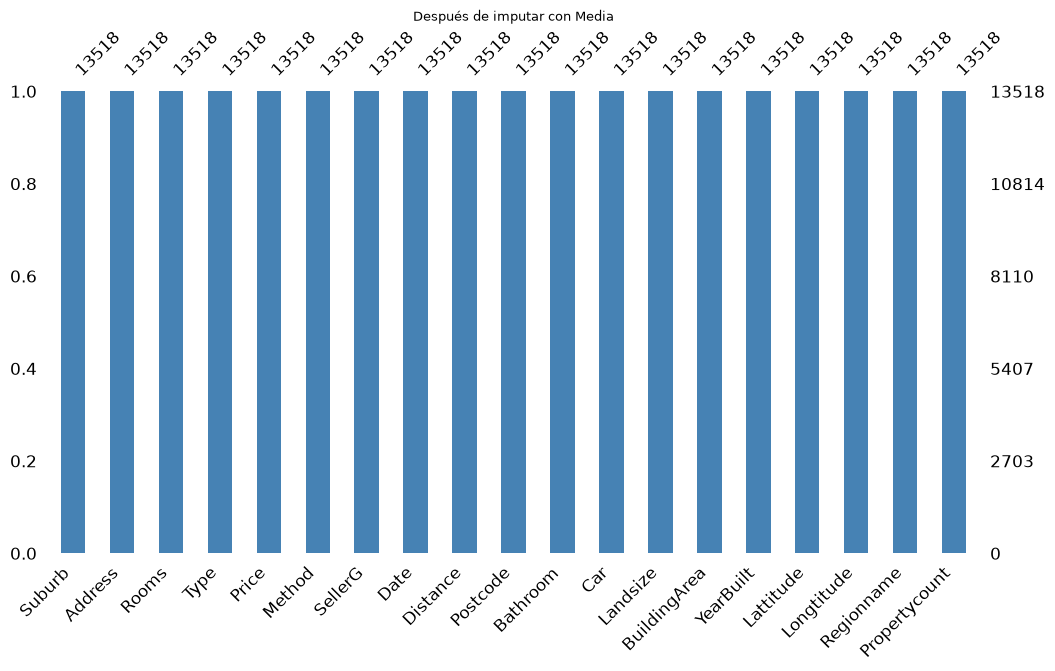

In [52]:

mean_imputer = SimpleImputer(strategy='mean')  # estrategia: media
# Tu código aquí ↓

#aplicar el reemplazo
melb_data_mean[['BuildingArea','YearBuilt']]= mean_imputer.fit_transform(melb_data_mean[['BuildingArea','YearBuilt']])

msno.bar(melb_data_mean, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputar con Media')

nota: simpleImputer(Strategy='mean') es un algoritmo matemático. Lo primero que hace al recibir el DataFrame es intentar convertir absolutamente todas las columnas a números par apoder calcular sus promedios. cuando llega la columna de texto donde lee una columnas que sea numérica intetará convertirla a float y eso generará un problema.

La forma de solucionarlo es fácil, simplemente seleccionar las variables numéricas o directamente en este caso fue seleccionar las variables que tenian los vacíos que directamente son numéricas y ya. 

`
melb_data_mean[columnas_numericas] = mean_imputer.fit_transform(melb_data_mean[columnas_numericas])`

al hacer esto, pandas no crea un DataFrame nuevo e independiente. Lo que hace es crear una vista o puntero en la RAM que apunta únicamente a las coordenadas desas columnas numéricas dentro del Data frame original y con el igual es que entonces se buscan las posiciones originales de memoria y se reemplazan los valores viejos con NA por lo nuevos en este caso que se llenan con media.

#### 2.2.4 Hot Deck

> 💡 Este método fue cubierto en las slides de Semana 5.

El **Hot Deck** reemplaza los faltantes con valores obtenidos de registros que son los más similares en el mismo dataset. Es conceptualmente más sofisticado que imputar con constantes o medias.

**Ventajas:**
- Conceptualmente simple.
- Conserva los niveles de medición adecuados para las variables.
- Finaliza el proceso de imputación con un conjunto completo de datos.

**Desventajas:**
- La dificultad principal es definir qué es "similar".

La librería `fancyimpute` implementa una versión iterativa equivalente:

In [54]:
#hay un error, el código presentado es de MICE no
# es de hot-deck

El código es MICE porque IterativeImputer (originario de scikit-leanr) implementa exactaente el algoritmo MICE

1. Imputaciones de valores faltantes con una estimación simple (media de cada columnas por ejemplo). 

2. Para cada columna con datos faltantess, la trata como variable independiente y entrena un modelo de regresión usando las demás columnas como variables predictoras.

3. Predice valores faltantes de esa columna con el modelo entrenado.

4. Repite este proceso columna por columna, en rondas sucesivas, actualizando las estimaciones hasta que converge

Hot-Deck es un método completamente distinto: consiste en rellenar un valor faltante copiando el valor de un registro "donante" real y similar dentrod el propio conjuntod e datos.

In [ ]:
#ALGORITMO MICE
from sklearn.experimental import enable_iterative_imputer  # necesario si usas sklearn en vez de fancyimpute
from sklearn.impute import IterativeImputer

data_mice = melb_df.copy()
data_mice_numeric = data_mice.select_dtypes(include='number')

imputer = IterativeImputer(imputation_order='ascending', random_state=0)
data_imputed = imputer.fit_transform(data_mice_numeric)

print("DataFrame imputado con MICE:")
print(pd.DataFrame(data_imputed, columns=data_mice_numeric.columns).sample(5))

DataFrame imputado con MICE:
       Rooms      Price  Distance  Postcode  Bathroom  Car  Landsize  \
9884    3.00  570000.00     38.00   3199.00      1.00 2.00    537.00   
4080    2.00  945000.00      6.90   3039.00      1.00 0.00    225.00   
6597    3.00 2368000.00      5.10   3181.00      2.00 1.00    322.00   
10062   4.00  716000.00     15.50   3038.00      2.00 2.00    684.00   
1567    3.00 1690000.00      7.80   3124.00      2.00 1.00    777.00   

       BuildingArea  YearBuilt  Lattitude  Longtitude  Propertycount  
9884         118.54    1960.00     -38.14      145.15       17055.00  
4080          97.00    1890.00     -37.76      144.91        6232.00  
6597         444.27    1970.00     -37.85      145.00        4380.00  
10062        271.14    1987.84     -37.69      144.77        5336.00  
1567         154.00    1950.00     -37.84      145.10        8920.00  


### UNA IDEA DE HOT-DECK
 no hay una versión oficial de sickit-learn. Las dos variantes
 más usadasd son Hot-deck aleatorio(dentro de grupos/estratos) y Hot-Deck por vecinos más
 cercanos KNN

In [ ]:
# Hot-Deck secuencial/aleatorio 

#Rellena cada valor faltante 
# copiando un valor real de otro 
# registro elegido al azar, opcionalmente
# dentro del mismo grupo o estrato 
# (por ejemplo, mismo Suburb o Type en tu dataset).

def hot_deck_imputation(df, column, group_cols=None, random_state=0):
    """
    Imputa valores faltantes en 'column' copiando un valor real (donante)
    de otro registro. Si se especifica group_cols, busca donantes solo
    dentro del mismo grupo (estrato).
    """
    rng = np.random.default_rng(random_state)
    df_imputed = df.copy()

    if group_cols:
        # Hot-Deck por estrato: busca donantes dentro del mismo grupo
        for _, grupo in df_imputed.groupby(group_cols):
            donantes = grupo[column].dropna().values
            faltantes_idx = grupo[grupo[column].isna()].index
            if len(donantes) > 0 and len(faltantes_idx) > 0:
                valores_donados = rng.choice(donantes, size=len(faltantes_idx))
                df_imputed.loc[faltantes_idx, column] = valores_donados
    else:
        # Hot-Deck simple: cualquier registro completo puede ser donante
        donantes = df_imputed[column].dropna().values
        faltantes_idx = df_imputed[df_imputed[column].isna()].index
        valores_donados = rng.choice(donantes, size=len(faltantes_idx))
        df_imputed.loc[faltantes_idx, column] = valores_donados

    return df_imputed

# Uso
data_hotdeck = melb_df.copy()
data_hotdeck = hot_deck_imputation(
    data_hotdeck,
    column='Price',
    group_cols=['Suburb', 'Type'],  # busca donantes en el mismo suburbio y tipo de propiedad
    random_state=42
)

print("DataFrame imputado con Hot Deck (aleatorio por estrato):")
print(data_hotdeck[['Suburb', 'Type', 'Price']].sample(5))

In [ ]:
#opción 2: Hot-Deck por vecino más cercano (KNN Hot-Deck)
# Esta variante busca el registro más parecido (según otras
#  variables numéricas) y copia su valor real.
#  Es la más usada en la práctica porque el donante
#  no es aleatorio sino "similar" al registro incompleto

from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

def knn_hot_deck(df, target_col, predictor_cols, n_neighbors=1):
    """
    Imputa target_col usando el valor real de su vecino más cercano
    (según predictor_cols), sin generar valores sintéticos.
    """
    df_imputed = df.copy()

    completos = df_imputed.dropna(subset=[target_col] + predictor_cols)
    incompletos = df_imputed[df_imputed[target_col].isna()].dropna(subset=predictor_cols)

    if incompletos.empty:
        return df_imputed

    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(completos[predictor_cols])

    distancias, indices = nn.kneighbors(incompletos[predictor_cols])

    # Toma el valor real del vecino más cercano (donante)
    valores_donados = completos.iloc[indices[:, 0]][target_col].values
    df_imputed.loc[incompletos.index, target_col] = valores_donados

    return df_imputed

# Uso
data_hotdeck_knn = melb_df.copy()
predictoras = ['Rooms', 'Distance', 'Landsize']  # variables sin NaN, usadas para medir similitud

data_hotdeck_knn = knn_hot_deck(
    data_hotdeck_knn,
    target_col='Price',
    predictor_cols=predictoras,
    n_neighbors=1
)

print("DataFrame imputado con Hot Deck (KNN):")
print(data_hotdeck_knn[['Price'] + predictoras].sample(5))

Nota importante: ambas producen valores que realmente existieron en el dataset (a diferencia de MICE, que genera estimaciones nuevas vía regresión). Eso es justamente lo que define a Hot-Deck y lo distingue de los métodos basados en modelos.

### 2.3 Técnicas de imputación avanzadas

Las técnicas avanzadas usan **algoritmos de aprendizaje automático** para imputar los valores del dataset, a diferencia de los métodos anteriores que usan otros valores de la misma columna.

### 2.3.1 K-Nearest Neighbor Imputation

KNN imputa valores faltantes encontrando los **k vecinos más cercanos** a la observación con datos perdidos y asignando el valor basado en los vecinos.

**Parámetros clave:**
- `n_neighbors`: número de vecinos más cercanos a considerar.
- `weights`: ponderación de los vecinos. `"uniform"` = todos contribuyen igual; `"distance"` = los más cercanos pesan más.

> ⚠️ KNN requiere que los datos estén **estandarizados** (diferentes escalas introducen valores sesgados).

Text(0.5, 1.0, 'Después de imputación KNN')

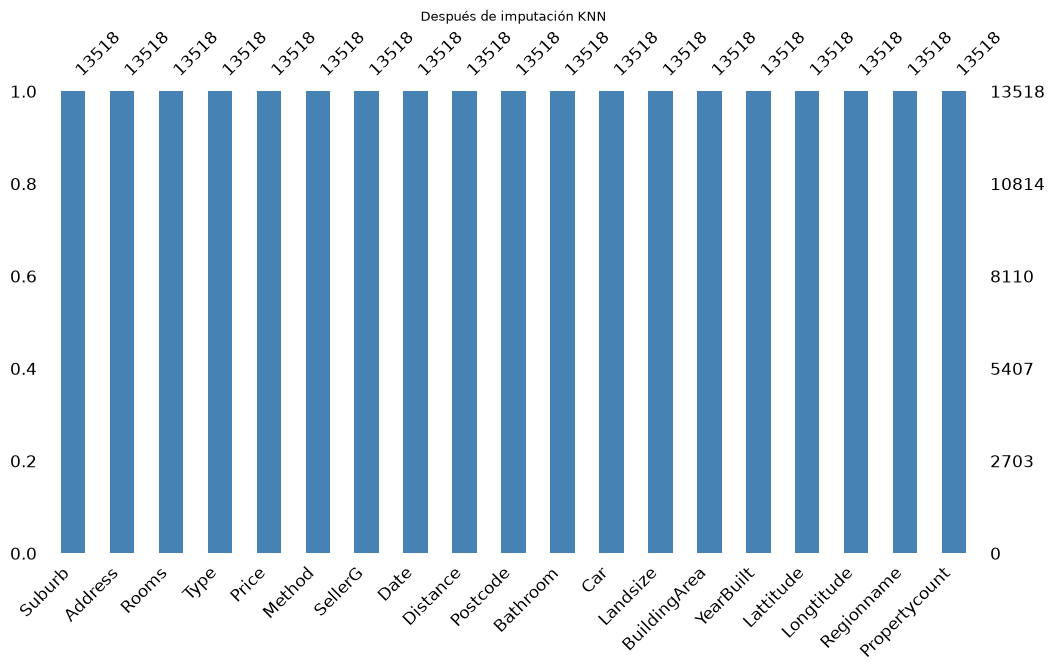

In [ ]:
melb_data_knn = melb_df.copy(deep=True)

#por ejemplo en este caso sucede lo mismo de seleccionar
#solamente las columnas con los datos faltantes.

knn_imputer = KNNImputer(n_neighbors=2, weights="uniform") #el peso uniforme es que todos los vecinos tiene 
#un peso similar. 
melb_data_knn[['YearBuilt', 'BuildingArea']] = knn_imputer.fit_transform(
    melb_data_knn[['YearBuilt', 'BuildingArea']])

msno.bar(melb_data_knn, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputación KNN')

In [ ]:
melb_data_knn.sample(10)

**Pros:**
- Considera la relación entre observaciones.
- Más preciso que métodos basados en estadísticos simples.

**Cons:**
- Usa distancias calculadas con los casos (incluso cuando tienen NaN).
- Requiere **codificación de variables categóricas** antes de imputar.
- Precisa que los datos estén estandarizados (`MinMaxScaler` de Scikit-Learn escala al rango [0, 1]).
- `CouncilArea` **no puede imputarse** sin encoding previo.

### 2.3.2 Multivariate feature imputation (MICE)

> 💡 Este método fue cubierto en detalle en las slides de Semana 5.

**MICE** (*Multivariate Imputation by Chained Equations*) es una estrategia que modela cada variable con valores faltantes como función de otras variables en forma rotatoria.

**Proceso (4 pasos repetidos por variable):**
1. **Paso 1** — Imputación simple inicial (media/moda) para completar todos los faltantes.
2. **Paso 2** — Se vuelve a poner `NA` en una variable X a imputar.
3. **Paso 3** — Se ajusta un modelo usando las demás variables completas para predecir X.
4. **Paso 4** — Los faltantes de X se reemplazan por las predicciones del modelo.

Los pasos 2–4 se repiten para cada variable con faltantes (= 1 ciclo). El proceso itera ~10 veces.

> 💡 MICE opera bajo el supuesto de que el mecanismo es **MAR**.

Text(0.5, 1.0, 'Después de imputación MICE (BayesianRidge)')

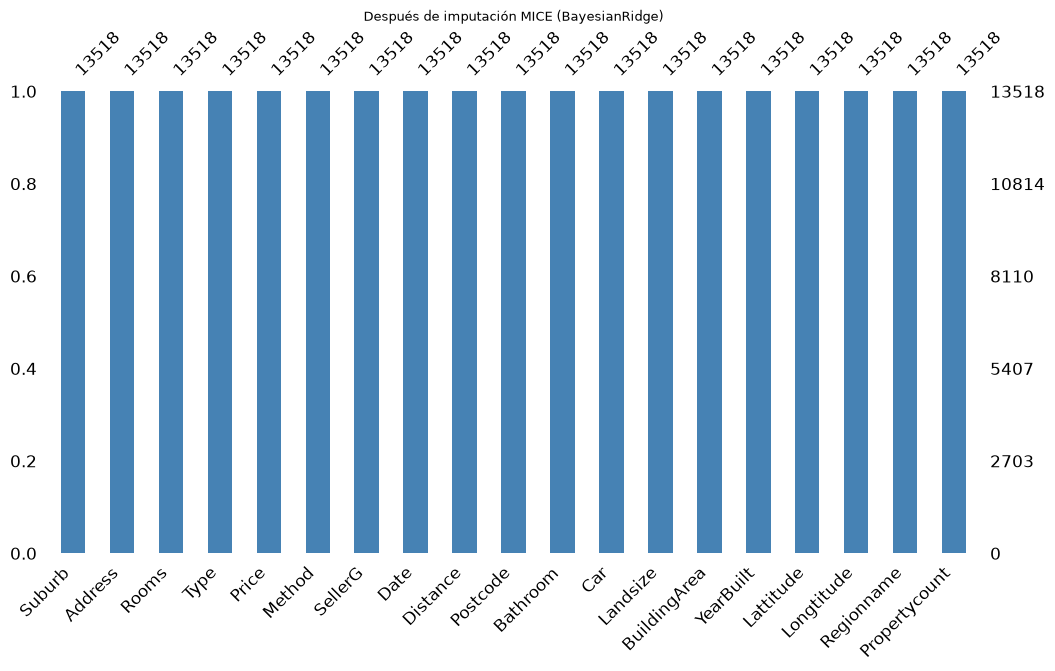

In [ ]:
melb_data_mice = melb_df.copy(deep=True)

mice_imputer = IterativeImputer(random_state=0, estimator=BayesianRidge())
melb_data_mice[['YearBuilt', 'BuildingArea']] = mice_imputer.fit_transform(
    melb_data_mice[['YearBuilt', 'BuildingArea']])

msno.bar(melb_data_mice, figsize=(12, 6), fontsize=12, color='steelblue')
plt.title('Después de imputación MICE (BayesianRidge)')

In [57]:
melb_data_mice.sample(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount
3512,Kensington,5 Rigby La,3,t,845000.00,S,Nelson,4/03/2017,4.20,3031.00,2.00,1.00,132.00,105.00,1961.28,-37.79,144.92,Northern Metropolitan,5263.00
2679,Footscray,8/19 Empire St,2,u,281000.00,S,Sweeney,10/12/2016,6.40,3011.00,1.00,1.00,0.00,65.00,1980.00,-37.79,144.89,Western Metropolitan,7570.00
5993,Sunshine,3/2 Cooper St,3,t,500000.00,PI,Douglas,27/06/2016,12.60,3020.00,1.00,2.00,224.00,159.00,1985.00,-37.79,144.84,Western Metropolitan,3755.00
4774,Port Melbourne,405/1 Danks St W,1,u,470000.00,SP,LITTLE,22/08/2016,3.80,3207.00,1.00,1.00,0.00,62.00,2000.00,-37.84,144.94,Southern Metropolitan,8648.00
2874,Glenroy,42 Sadie St,3,h,822000.00,S,Stockdale,4/03/2017,13.00,3046.00,1.00,4.00,700.00,105.00,1950.00,-37.70,144.94,Northern Metropolitan,8870.00
7533,Bentleigh East,68 Mawby Rd,3,h,1165000.00,S,Buxton,29/04/2017,13.90,3165.00,1.00,2.00,589.00,158.00,1965.82,-37.93,145.06,Southern Metropolitan,10969.00
1493,Bulleen,28 Kenneth St,4,h,976000.00,S,Barry,18/06/2016,11.80,3105.00,1.00,1.00,701.00,154.39,1965.51,-37.78,145.09,Eastern Metropolitan,4480.00
4671,Pascoe Vale,5 Virginia St,3,h,600000.00,PI,Re,23/04/2016,9.90,3044.00,1.00,4.00,557.00,111.00,1955.00,-37.72,144.94,Northern Metropolitan,7485.00
11827,Taylors Hill,55 Bloomsbury Dr,3,h,520000.00,S,Barry,22/07/2017,18.00,3037.00,2.00,2.00,389.00,161.00,2005.00,-37.71,144.76,Western Metropolitan,4242.00
9595,Huntingdale,50 Ross St,4,h,1145000.00,S,Ray,17/06/2017,12.30,3166.00,1.00,2.00,603.00,151.00,1960.00,-37.91,145.11,Southern Metropolitan,768.00


**Pros:**
- Versátil — puede utilizarse con diferentes clases de estimadores.
- No produce sesgo importante cuando el mecanismo es MAR.
- Se puede usar para cualquier tipo de análisis posterior.

**Cons:**
- La versión de Sklearn **no admite datos mixtos** — debe realizarse encoding primero.
- Puede ser costoso computacionalmente.
- Genera un dataset completo por cada iteración.

### 2.3.3 Ejercicio

Dado `melb_df`, imputar las columnas `YearBuilt` y `BuildingArea` con cada uno de los siguientes estimadores y comparar resultados:

- `BayesianRidge()`
- `DecisionTreeRegressor(max_features='sqrt', random_state=0)`
- `ExtraTreesRegressor(n_estimators=10, random_state=0)`
- `KNeighborsRegressor(n_neighbors=15)`

In [63]:
estimators = {
    'BayesianRidge': BayesianRidge(),
    'DecisionTree': DecisionTreeRegressor(max_features='sqrt', random_state=0),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=10, random_state=0),
    'KNeighbors': KNeighborsRegressor(n_neighbors=15)
}

# Tu código aquí ↓
# Para cada estimador en estimators:
#   - Crear una copia de melb_df
#   - Imputar YearBuilt y BuildingArea con IterativeImputer(estimator=...)
#   - Mostrar estadísticos descriptivos de las columnas imputadas
def mice_estimadores(estimador):
    melb_data_mice = melb_df.copy(deep=True)

    mice_imputer = IterativeImputer(random_state=0, estimator=estimators[estimador])
    melb_data_mice[['YearBuilt', 'BuildingArea']] = mice_imputer.fit_transform(
    melb_data_mice[['YearBuilt', 'BuildingArea']])

    print()
    print("-"*30)
    print(f"Estimador {estimador}")
    print(melb_data_mice[['YearBuilt', 'BuildingArea']].describe())
    print("-"*30)
    print()

In [65]:
mice_estimadores('BayesianRidge')
mice_estimadores('DecisionTree')
mice_estimadores('ExtraTrees')
mice_estimadores('KNeighbors')


------------------------------
Estimador BayesianRidge
       YearBuilt  BuildingArea
count   13518.00      13518.00
mean     1965.51        154.39
std        44.00        400.17
min      1196.00       -664.03
25%      1960.00        115.00
50%      1965.51        154.39
75%      1975.00        154.39
max      5765.76      44515.00
------------------------------


------------------------------
Estimador DecisionTree
       YearBuilt  BuildingArea
count   13518.00      13518.00
mean     1965.80        158.32
std        29.00        393.28
min      1196.00          0.00
25%      1960.00        118.00
50%      1967.28        170.00
75%      1975.00        170.00
max      2018.00      44515.00
------------------------------



/home/mgtdev/documentos_estudio/ESTADISTICA/IMD/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



------------------------------
Estimador ExtraTrees
       YearBuilt  BuildingArea
count   13518.00      13518.00
mean     1970.95        155.56
std        29.99        393.20
min      1196.00          0.00
25%      1960.00        118.00
50%      1981.00        162.80
75%      1981.00        162.80
max      2018.00      44515.00
------------------------------


------------------------------
Estimador KNeighbors
       YearBuilt  BuildingArea
count   13518.00      13518.00
mean     1960.74       1513.04
std        29.41       1800.95
min      1196.00          0.00
25%      1953.87        117.00
50%      1953.87        183.99
75%      1975.00       3780.20
max      2018.00      44515.00
------------------------------



/home/mgtdev/documentos_estudio/ESTADISTICA/IMD/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### 2.3.4 Otros métodos de imputación

- **[miceforest](https://github.com/AnotherSamWilson/miceforest)** — MICE rápido con Random Forests. Puede imputar datos categóricos y numéricos sin mucha configuración.

- **[MissForest (missingpy)](https://towardsdatascience.com/missforest-the-best-missing-data-imputation-algorithm-4d01182aed3)** — Imputa usando Random Forests de forma iterativa.

- **[Datawig](https://github.com/awslabs/datawig)** — Imputación con Deep Learning. Funciona muy bien con características categóricas y no numéricas.

- **Stochastic regression imputation** — Similar a la imputación por regresión, pero agrega un residuo aleatorio para no subestimar la varianza.

- **Extrapolación e Interpolación** — Estima valores a partir de observaciones dentro del rango conocido.

- **Cold Deck** — Sustituye un valor constante derivado de fuentes externas o investigaciones previas. Tiene las mismas desventajas que imputar con la media.

### Conclusión

No existe una forma perfecta de compensar los valores perdidos. Cada estrategia puede funcionar mejor para ciertos conjuntos de datos y tipos de faltantes.

**Guía de decisión rápida:**

| Situación | Estrategia sugerida |
|---|---|
| Pocos faltantes, mecanismo MCAR | Eliminación de casos |
| Variable con >80% faltantes | Eliminación de variable |
| Faltantes en variable numérica, MAR | Imputación por media/mediana o KNN |
| Faltantes en variable categórica | Imputación por moda o Hot Deck |
| Faltantes en múltiples variables relacionadas | MICE |
| MNAR | Modelado explícito del mecanismo; consultar con experto de dominio |

> La clave es siempre **entender por qué faltan los datos** antes de decidir qué hacer con ellos.